Indexing images in: /mnt/ssd2tb/boat/thesis/s21fe_dataset/processed_v16.1
Using cache: True
Displaying top 20 images by score.
Loading index from cache: /mnt/ssd2tb/boat/thesis/s21fe_dataset/image_index_cache.json


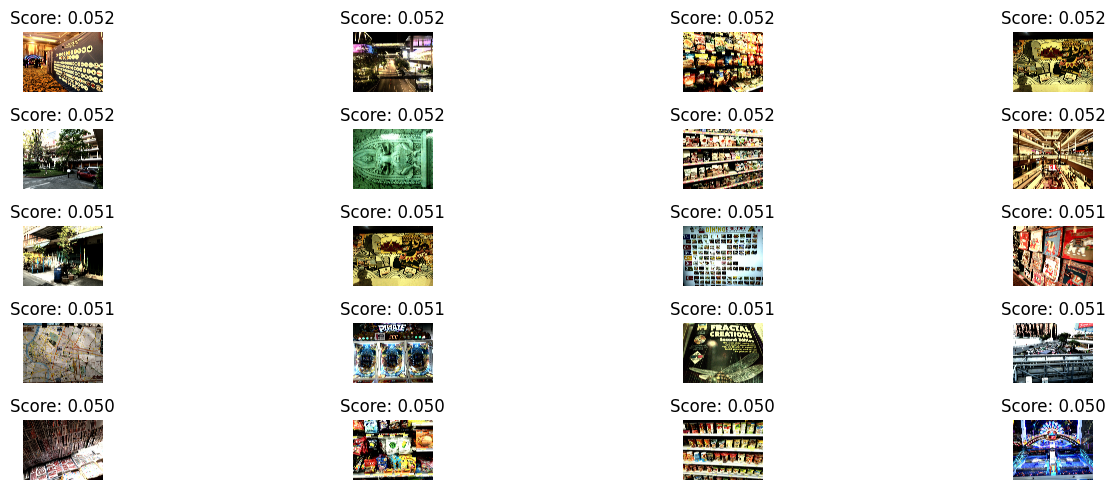

In [39]:
import os
import json
import argparse
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import tqdm
import math

# def compute_contrast_score(gray_image):
#     """Lower contrast should result in higher score (inverted Michelson contrast)."""
#     min_intensity = np.min(gray_image)
#     max_intensity = np.max(gray_image)

#     if max_intensity + min_intensity == 0:
#         contrast = 0
#     else:
#         contrast = (max_intensity - min_intensity) / (max_intensity + min_intensity)

#     # Invert contrast: lower original contrast gets higher score
#     contrast_score = 1 - contrast
#     return contrast_score

def compute_color_variation_score(image):
    """
    Compute color variation as the mean standard deviation across color channels.
    Higher stddev → more color variation → higher score.
    """
    # Split into R, G, B channels
    channels = cv2.split(image)  # Returns list: [B, G, R]
    stddevs = [np.std(c) for c in channels]
    mean_stddev = np.mean(stddevs)

    return mean_stddev

def compute_contrast_score(gray_image):
    """Lower contrast (lower stddev) should result in a higher score."""
    stddev = np.std(gray_image)
    # Invert stddev so that lower contrast gets higher score
    contrast_score = 1 / (stddev + 1e-5)  # Avoid division by zero
    return contrast_score

def compute_edge_score(gray_image):
    """Compute the edge richness using Sobel gradients after applying a fast blur."""
    # Apply a fast Gaussian blur to suppress noise
    blurred = cv2.GaussianBlur(gray_image, (9, 9), 0)  # (5,5) kernel is a good default

    # Apply Sobel gradients to the blurred image
    sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

    # Normalize magnitude to [0, 1], then average as edge richness score
    normalized_magnitude = gradient_magnitude / (np.max(gradient_magnitude) + 1e-8)
    edge_score = np.mean(normalized_magnitude)

    return edge_score
    
def index_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Cannot read image: {image_path}")
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    contrast_score = compute_contrast_score(gray)
    edge_score = compute_edge_score(gray)
    # color_score = compute_color_variation_score(image)

    # Normalize color_score (optional: if range is inconsistent)
    # normalized_color_score = color_score / 128.0  # assuming max stddev ~128
    normalized_color_score = None

    # total_score = (contrast_score + edge_score + normalized_color_score) / 3
    total_score = (0.5 * contrast_score) + (0.5 * edge_score)

    return {
        'image_path': image_path,
        'contrast_score': contrast_score,
        'edge_score': edge_score,
        'color_variation_score': normalized_color_score,
        'total_score': total_score
    }


def index_images_in_folder(folder_path, use_cache=True):
    cache_path = os.path.join(os.path.dirname(folder_path.rstrip("/\\")), "image_index_cache.json")
    
    if use_cache and os.path.exists(cache_path):
        print(f"Loading index from cache: {cache_path}")
        with open(cache_path, 'r') as f:
            return json.load(f)
    
    print("Indexing images...")
    image_files = glob(os.path.join(folder_path, "**", "*.*"), recursive=True)
    image_files = [f for f in image_files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

    indexed = []
    for path in tqdm.tqdm(image_files):
        try:
            indexed.append(index_image(path))
        except Exception as e:
            print(f"Failed to index {path}: {e}")
    
    indexed.sort(key=lambda x: x['total_score'], reverse=True)

    with open(cache_path, 'w') as f:
        json.dump(indexed, f, indent=2)

    return indexed


def best_rectangle(area):
    best_w, best_h = 1, area
    min_diff = area  # start with the worst possible difference

    for h in range(1, int(math.sqrt(area)) + 1):
        if area % h == 0:
            w = area // h
            if abs(w - h) < min_diff:
                best_w, best_h = w, h
                min_diff = abs(w - h)

    return best_w, best_h
    
def plot_top_k(indexed_images, k=5):
    # top_k = indexed_images[:k]
    top_k = indexed_images[100-k:100]
    plt.figure(figsize=(15, 5))

    area = k  # or any number
    side_length = math.sqrt(area)
    rounded_side = round(side_length)
    
    w,h = best_rectangle(k)

    # print("best_square_area", best_square_area)
    
    for i, entry in enumerate(top_k):
        img = cv2.imread(entry['image_path'])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(w, h, i + 1)
        plt.imshow(img_rgb)
        plt.title(f"Score: {entry['total_score']:.3f}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

image_dir = "/mnt/ssd2tb/boat/thesis/s21fe_dataset/processed_v16.1"  
topk = 20
use_cache = True   

print(f"Indexing images in: {image_dir}")
print(f"Using cache: {use_cache}")
print(f"Displaying top {topk} images by score.")

indexed_images = index_images_in_folder(image_dir, use_cache=use_cache)
plot_top_k(indexed_images, k=topk)



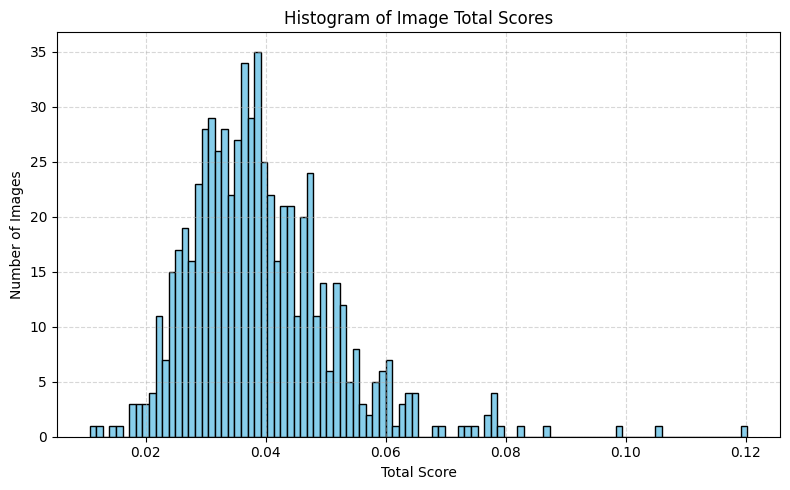

In [33]:
import matplotlib.pyplot as plt

def plot_score_histogram(indexed_images, score_key="total_score", bins=20):
    """Plot histogram of image index scores."""
    scores = [img[score_key] for img in indexed_images]

    plt.figure(figsize=(8, 5))
    plt.hist(scores, bins=bins, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of Image {score_key.replace('_', ' ').title()}s")
    plt.xlabel(score_key.replace('_', ' ').title())
    plt.ylabel("Number of Images")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_score_histogram(indexed_images, bins=100)

In [34]:
import os
import shutil

def find_raw_file(raw_image_dir, target_filename):
    """Recursively search for a raw .dng file by filename."""
    for root, _, files in os.walk(raw_image_dir):
        for f in files:
            if f.lower() == target_filename.lower():
                return os.path.join(root, f)
    return None

def select_and_copy_top_k_raw(indexed_images, k=10,
                               raw_image_dir="raw_images",
                               output_folder="top_k_raw",
                               processed_image_dir="top_k_processed"):
    """
    Select top-k images by score and copy their corresponding raw (.dng)
    and processed (.jpg/.png) files.

    Parameters:
        indexed_images (list): List of dicts with keys 'image_path' and 'total_score'
        k (int): Number of top images to copy
        raw_image_dir (str): Directory containing raw .dng files with matching names
        output_folder (str): Destination folder to copy the raw images
        processed_image_dir (str): Destination for the processed image files
    """
    os.makedirs(output_folder, exist_ok=False)
    os.makedirs(processed_image_dir, exist_ok=False)

    sorted_images = sorted(indexed_images, key=lambda x: x['total_score'], reverse=True)
    top_k_images = sorted_images[:k]

    print(f"\n📦 Copying top {k} raw and processed images...")
    copied_raw = 0
    copied_proc = 0

    for idx, img_data in enumerate(top_k_images):
        base_name = os.path.splitext(os.path.basename(img_data['image_path']))[0]
        raw_filename = base_name + ".dng"

        # -- Copy raw .dng
        raw_path = find_raw_file(raw_image_dir, raw_filename)
        if raw_path and os.path.exists(raw_path):
            dst_raw = os.path.join(output_folder, f"{idx+1:02d}_{raw_filename}")
            shutil.copy2(raw_path, dst_raw)
            copied_raw += 1
            print(f"✅ Raw copied: {dst_raw}")
        else:
            print(f"⚠️ Raw file not found: {raw_filename}")

        # -- Copy processed image
        proc_src = img_data['image_path']
        if os.path.exists(proc_src):
            ext = os.path.splitext(proc_src)[1]
            dst_proc = os.path.join(processed_image_dir, f"{idx+1:02d}_{base_name}{ext}")
            shutil.copy2(proc_src, dst_proc)
            copied_proc += 1
            print(f"✅ Processed copied: {dst_proc}")
        else:
            print(f"⚠️ Processed image not found: {proc_src}")

    print(f"\n✨ Done. Copied {copied_raw} raw images and {copied_proc} processed images.\n")

# Example usage
output_folder = "/mnt/ssd2tb/boat/thesis/s21fe_dataset/raw_edgeContrastIndex_top100"
processed_image_dir = "/mnt/ssd2tb/boat/thesis/s21fe_dataset/processed_edgeContrastIndex_top100"
raw_image_dir = "/mnt/ssd2tb/boat/thesis/s21fe_dataset/raw"

# Make sure `indexed_images` is already loaded/available in your script
select_and_copy_top_k_raw(
    indexed_images,
    k=100,
    raw_image_dir=raw_image_dir,
    output_folder=output_folder,
    processed_image_dir=processed_image_dir
)


📦 Copying top 100 raw and processed images...
✅ Raw copied: /mnt/ssd2tb/boat/thesis/s21fe_dataset/raw_edgeContrastIndex_top100/01_20240115_161923.dng
✅ Processed copied: /mnt/ssd2tb/boat/thesis/s21fe_dataset/processed_edgeContrastIndex_top100/01_20240115_161923.jpg
✅ Raw copied: /mnt/ssd2tb/boat/thesis/s21fe_dataset/raw_edgeContrastIndex_top100/02_20250312_194033.dng
✅ Processed copied: /mnt/ssd2tb/boat/thesis/s21fe_dataset/processed_edgeContrastIndex_top100/02_20250312_194033.jpg
✅ Raw copied: /mnt/ssd2tb/boat/thesis/s21fe_dataset/raw_edgeContrastIndex_top100/03_20240116_135153.dng
✅ Processed copied: /mnt/ssd2tb/boat/thesis/s21fe_dataset/processed_edgeContrastIndex_top100/03_20240116_135153.jpg
✅ Raw copied: /mnt/ssd2tb/boat/thesis/s21fe_dataset/raw_edgeContrastIndex_top100/04_20240115_162128.dng
✅ Processed copied: /mnt/ssd2tb/boat/thesis/s21fe_dataset/processed_edgeContrastIndex_top100/04_20240115_162128.jpg
✅ Raw copied: /mnt/ssd2tb/boat/thesis/s21fe_dataset/raw_edgeContrastIndex